# OPTUNA 66 multi-year model skill analysis

This notebook is a thin interactive report. All calculations and plotting functions live in `model_skill_metrics.py`. The default analysis uses jointly finite model–observation pairs, pools samples before calculating multi-year statistics, excludes primary production and benthic variables, and includes CHRP whenever observations are available.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

from model_skill_metrics import run_analysis

RUN_NAME = "OPTUNA_66"
YEARS = [2005, 2006]  # Add 2007 here after its cost file is ready.
INPUT_ROOT = Path("/Users/akbaskind/Desktop/COST_FILES")
OUTPUT_ROOT = Path("/Users/akbaskind/Desktop/SKILL")
WEIGHTS_PATH = Path("skill_priority_weights.csv")
YEAR_RANGE = f"{min(YEARS)}-{max(YEARS)}" if len(YEARS) > 1 else str(YEARS[0])
OUTPUT_DIR = OUTPUT_ROOT / RUN_NAME / YEAR_RANGE
OUTPUT_DIR

PosixPath('/Users/akbaskind/Desktop/SKILL/OPTUNA_66/2005-2006')

## Run or refresh the analysis

Set `RUN_ANALYSIS = True` to regenerate all tables and figures. Existing generated files are replaced only when `OVERWRITE = True`. Priority weights can be changed in `skill_priority_weights.csv`; a copy of the applied weights is saved with every analysis.

In [2]:
RUN_ANALYSIS = True
OVERWRITE = True

if RUN_ANALYSIS:
    result = run_analysis(
        run_name=RUN_NAME,
        years=YEARS,
        input_root=INPUT_ROOT,
        output_root=OUTPUT_ROOT,
        weights_path=WEIGHTS_PATH,
        include_optional=(),
        overwrite=OVERWRITE,
    )
    display(result["cost_summary"])

,period,period_type,weighted_cost_sum,weighted_cost_mean,included_component_count,excluded_component_count,included_priority_weight_sum,expected_component_count
0,2005,annual,14.483001,0.965533,15,6,15.0,21
1,2006,annual,23.032765,1.279598,18,3,18.0,21
2,2005-2006 pooled,pooled,20.240329,1.124463,18,3,18.0,21


## Inspect generated tables

In [3]:
tables = OUTPUT_DIR / "tables"
metrics = pd.read_csv(tables / "metrics.csv")
cost_components = pd.read_csv(tables / "ward_cost_components.csv")
cost_summary = pd.read_csv(tables / "ward_cost_summary.csv")
coverage = pd.read_csv(tables / "data_coverage.csv")

display(cost_summary)
display(metrics.loc[metrics["period_type"].eq("pooled")])

,period,period_type,weighted_cost_sum,weighted_cost_mean,included_component_count,excluded_component_count,included_priority_weight_sum,expected_component_count
0,2005,annual,14.483001,0.965533,15,6,15.0,21
1,2006,annual,23.032765,1.279598,18,3,18.0,21
2,2005-2006 pooled,pooled,20.240329,1.124463,18,3,18.0,21


,period,period_type,year,source,variable,variable_key,depth,units,component,n,...,correlation,bias,bias_star,rmse,rmse_star,rmse_centered,rmse_centered_star,target_x,ward_cost,identity_error
62,2005-2006 pooled,pooled,NaN,NBFSMN,Temperature,temperature,Surface,°C,temperature__surface,3299,...,0.993764,0.030733,0.004505,0.766005,0.112287,0.765389,0.112197,0.112197,0.012608,3.469447e-18
63,2005-2006 pooled,pooled,NaN,NBFSMN,Temperature,temperature,Bottom,°C,temperature__bottom,2563,...,0.987979,0.501563,0.084999,1.112815,0.188587,0.993374,0.168346,0.168346,0.035565,-8.326673e-17
64,2005-2006 pooled,pooled,NaN,NBFSMN,Temperature,temperature,Total,°C,temperature__total,5862,...,0.990667,0.236591,0.036748,0.933625,0.145012,0.903150,0.140279,0.140279,0.021029,6.938894e-18
65,2005-2006 pooled,pooled,NaN,NBFSMN,Salinity,salinity,Surface,PSU,salinity__surface,3299,...,0.980595,0.713389,0.097117,1.607266,0.218805,1.440271,0.196071,-0.196071,0.047875,3.469447e-17
66,2005-2006 pooled,pooled,NaN,NBFSMN,Salinity,salinity,Bottom,PSU,salinity__bottom,2563,...,0.969098,0.298031,0.056523,1.341918,0.254502,1.308404,0.248146,-0.248146,0.064771,1.526557e-16
67,2005-2006 pooled,pooled,NaN,NBFSMN,Salinity,salinity,Total,PSU,salinity__total,5862,...,0.977340,0.531785,0.080466,1.497047,0.226523,1.399412,0.211750,-0.211750,0.051313,6.938894e-17
68,2005-2006 pooled,pooled,NaN,NBFSMN,pH,ph,Surface,NBS,ph__surface,3299,...,0.756890,0.076190,0.229711,0.232049,0.699619,0.219184,0.660833,-0.660833,0.489467,9.992007e-16
69,2005-2006 pooled,pooled,NaN,NBFSMN,pH,ph,Bottom,NBS,ph__bottom,2563,...,0.834372,0.145842,0.504482,0.221331,0.765605,0.166486,0.575889,0.575889,0.586150,2.220446e-16
70,2005-2006 pooled,pooled,NaN,NBFSMN,pH,ph,Total,NBS,ph__total,5862,...,0.788134,0.106644,0.331838,0.227425,0.707667,0.200871,0.625041,-0.625041,0.500793,-1.998401e-15
71,2005-2006 pooled,pooled,NaN,NBFSMN,Dissolved oxygen,oxygen,Surface,mmol m⁻³,oxygen__surface,3299,...,0.751505,7.564651,0.119201,42.558448,0.670619,41.880754,0.659940,-0.659940,0.449729,0.000000e+00


## Main skill diagrams

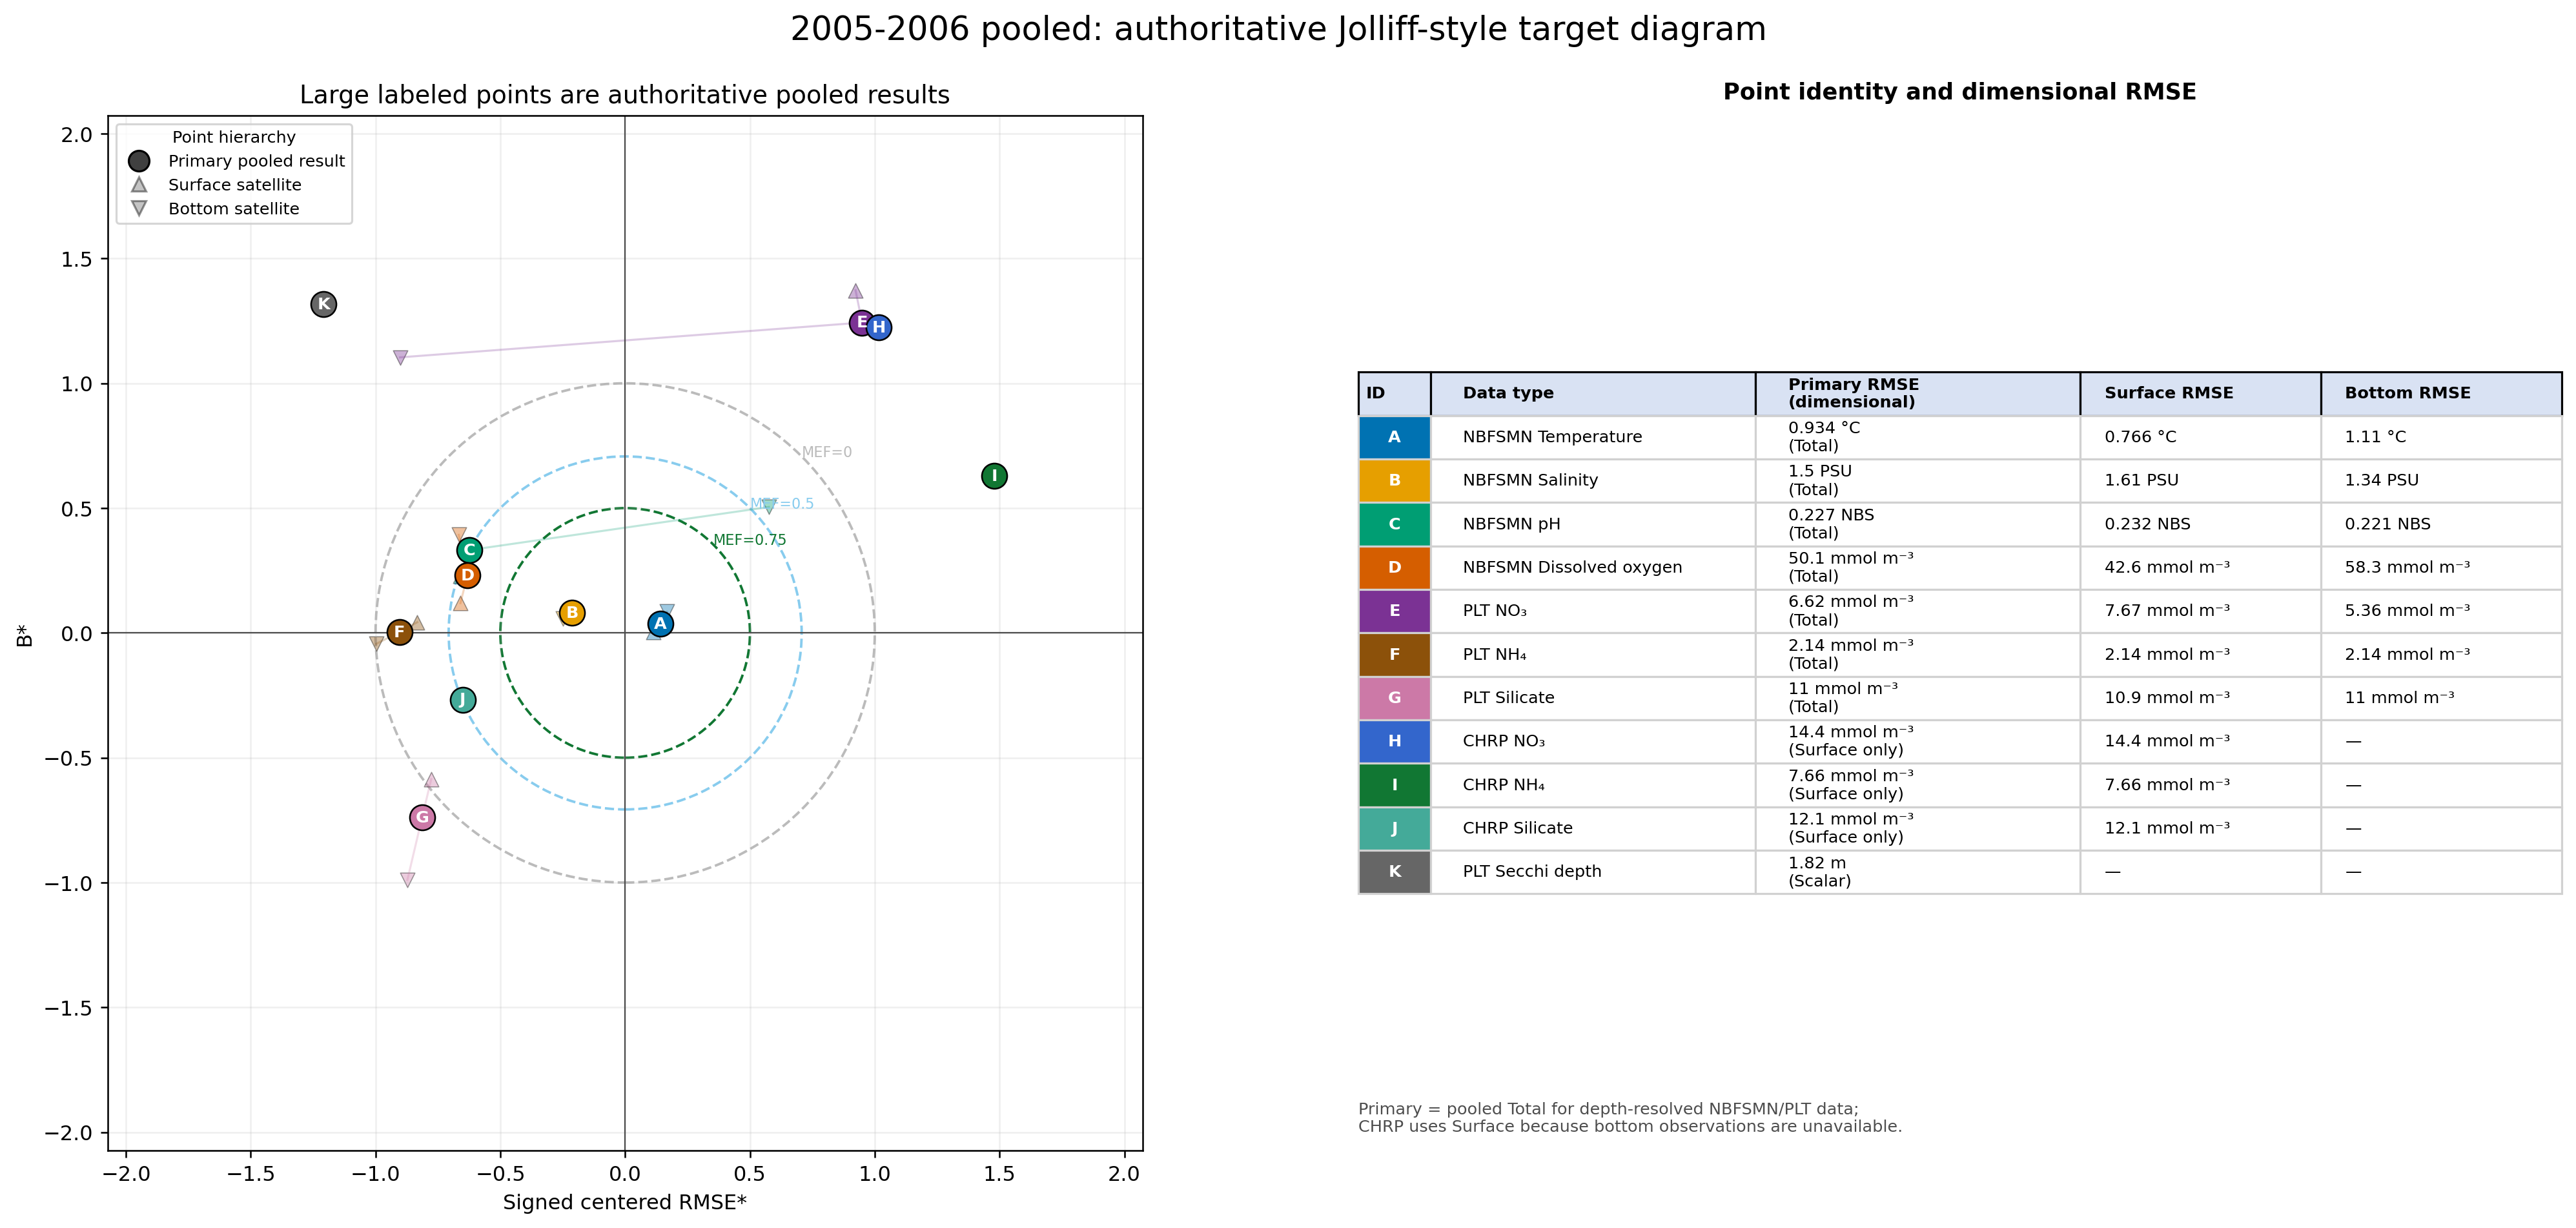

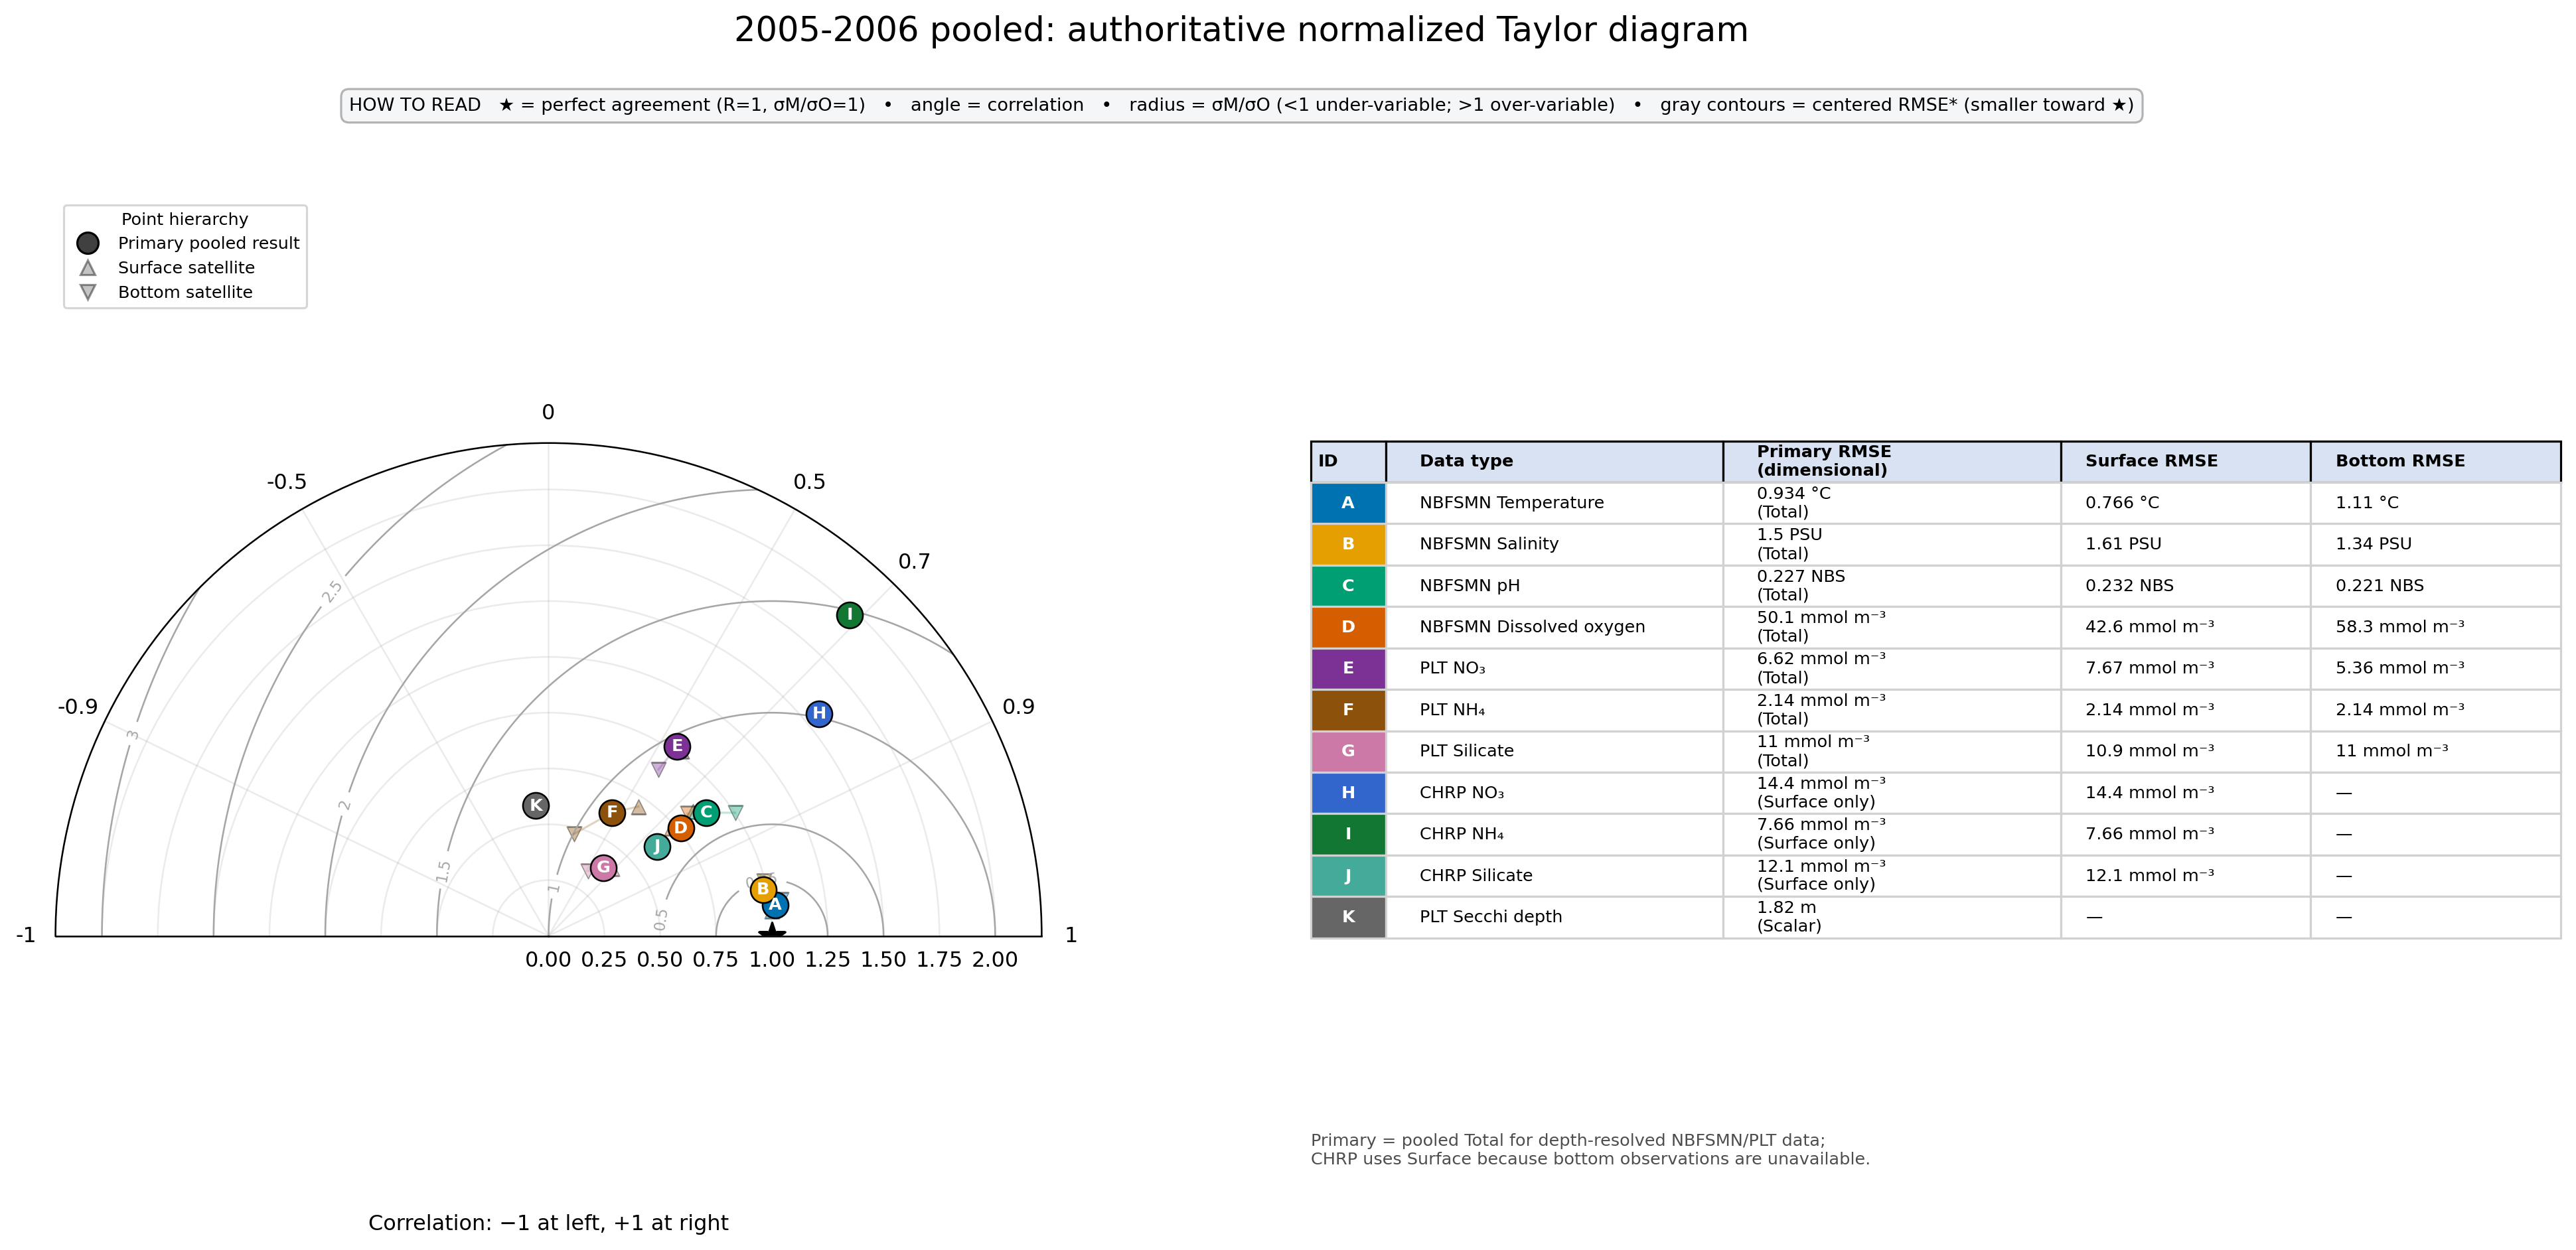

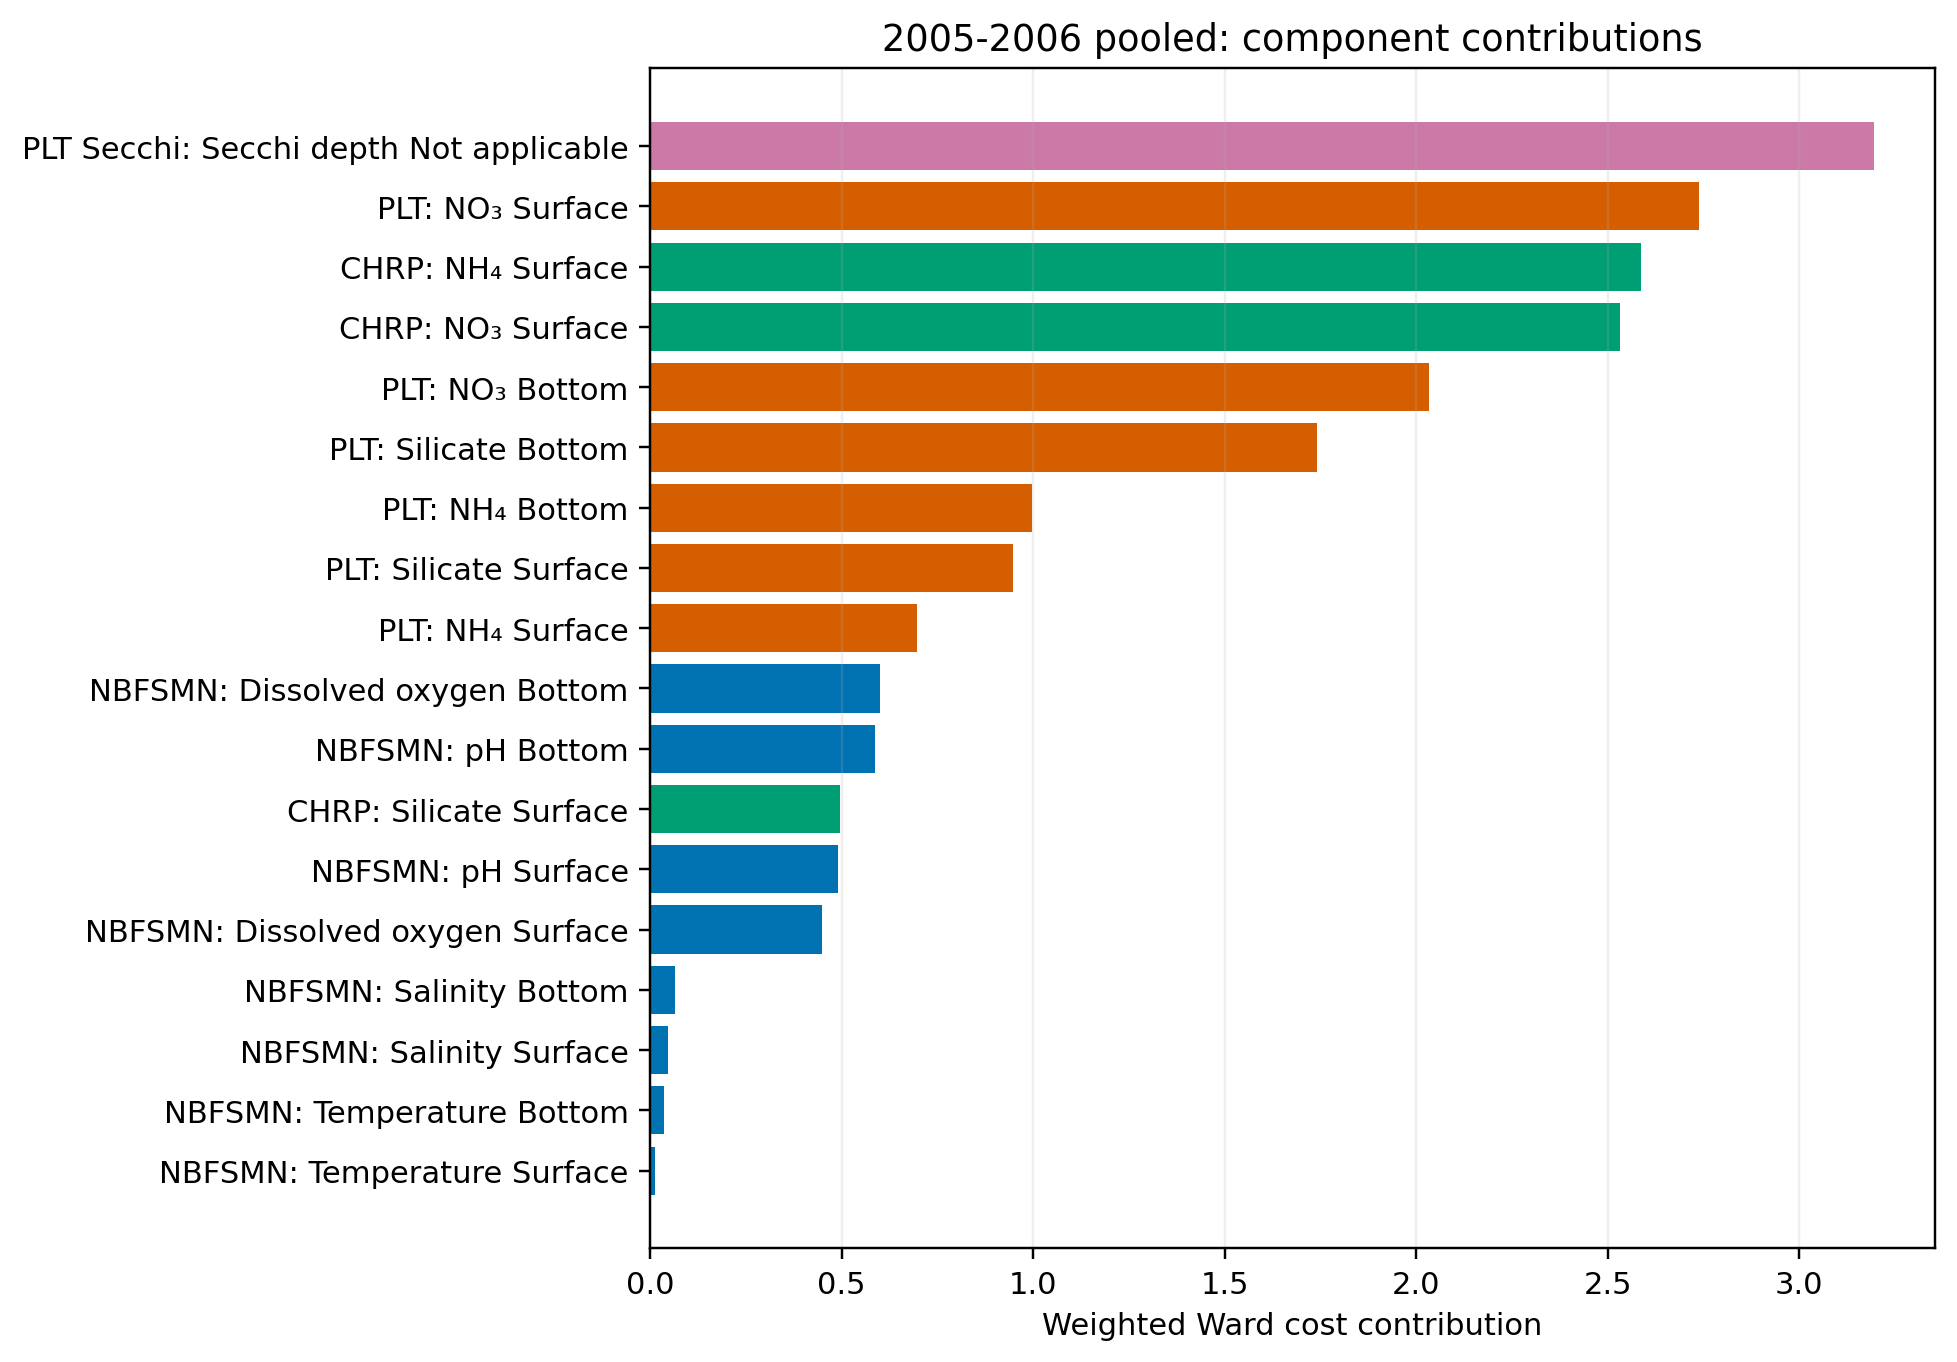

In [4]:
display(Image(filename=str(OUTPUT_DIR / "figures/target/target_diagram_pooled.png")))
display(Image(filename=str(OUTPUT_DIR / "figures/taylor/taylor_diagram_pooled.png")))
display(Image(filename=str(OUTPUT_DIR / "figures/cost/ward_cost_components.png")))

Time-series and residual figures are organized by observation source under `figures/time_series/`.